## Medication escalation prediction / duration prediction performance plots

KR and JMDC escalation prediction / duration prediction figures.

In [12]:
from __future__ import annotations

import ast
import json
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_curve

%matplotlib inline

CWD = Path.cwd().resolve()
FIGURE_DIR = CWD if (CWD / 'figutils').exists() else CWD / 'figure'
PROJECT_ROOT = FIGURE_DIR.parent
OUT_DIR = FIGURE_DIR / 'out'
OUT_DIR.mkdir(parents=True, exist_ok=True)

font_path = FIGURE_DIR / 'figutils' / 'Helvetica.ttf'
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = fm.FontProperties(fname=str(font_path)).get_name()

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

USE_DRUG_COND = True

RESULT_CONFIG = {
    'KR': {
        'metrics': PROJECT_ROOT / 'results' / '0506' / 'KR_rerun_full' / 'val_composite_metrics.json',
    },
    'JMDC': {
        'metrics': PROJECT_ROOT / 'results' / '0506' / 'JMDC_out0506_ckpt_full' / 'extval_jmdc_composite_fields_full.json',
    },
}

RAW_PRED_CONFIG = {
    'KR': PROJECT_ROOT / 'results' / 'shift_total_raw' / 'val_composite_raw_predictions.npz',
    'JMDC': PROJECT_ROOT / 'results' / '0506' / 'JMDC_out0506_ckpt_full' / 'extval_jmdc_composite_raw_predictions_full.npz',
}

PALETTE = {'KR': '#2F6B9A', 'JMDC': '#C05A3D'}

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'OUT_DIR      = {OUT_DIR}')


PROJECT_ROOT = /home/hsh/hsh/GPT-Disease-Drug-Prediction
OUT_DIR      = /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out


In [17]:
def parse_maybe_literal(value):
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return value
    return value


def load_metrics(config):
    loaded = {}
    for dataset, item in config.items():
        path = Path(item['metrics'])
        if not path.exists():
            raise FileNotFoundError(f'Missing metrics file for {dataset}: {path}')
        with path.open() as f:
            loaded[dataset] = {'path': path, 'metrics': json.load(f)}
    return loaded


def pick_metric(metrics, base_key, prefer_drug_cond=True):
    if prefer_drug_cond:
        drug_key = f'{base_key}_drug_cond'
        if drug_key in metrics:
            return metrics[drug_key], 'drug_cond'
    if base_key in metrics:
        return metrics[base_key], 'all'
    return np.nan, 'missing'


def get_shift_confusion_payload(metrics, prefer_drug_cond=True):
    suffixes = ['_drug_cond', ''] if prefer_drug_cond else ['', '_drug_cond']
    for suffix in suffixes:
        cm_key = f'shift_confusion_matrix{suffix}'
        if cm_key not in metrics:
            continue
        classes_key = f'shift_confusion_matrix_classes{suffix}'
        alt_classes_key = f'shift_confusion_matrix{suffix}_classes'
        class_map_key = f'shift_class_name_map{suffix}'
        cm = np.asarray(parse_maybe_literal(metrics[cm_key]), dtype=float)
        classes = parse_maybe_literal(metrics.get(classes_key, metrics.get(alt_classes_key, list(range(cm.shape[0])))))
        class_map = parse_maybe_literal(metrics.get(class_map_key, {})) or {}
        names = [str(class_map.get(str(cls), class_map.get(cls, cls))) for cls in classes]
        return {
            'cm': cm,
            'classes': classes,
            'class_names': names,
            'scope': 'drug_cond' if suffix == '_drug_cond' else 'all',
        }
    return None


def build_shift_summary(records, prefer_drug_cond=True):
    metric_map = {
        'accuracy': 'shift_accuracy',
        'balanced_accuracy': 'shift_balanced_accuracy',
        'roc_auc': 'shift_roc_auc',
        'f1_macro': 'shift_f1_macro',
        'f1_binary': 'shift_f1_binary',
        'support': 'shift_support',
    }
    rows = []
    for dataset, record in records.items():
        metrics = record['metrics']
        row = {'dataset': dataset, 'source_file': str(record['path'].relative_to(PROJECT_ROOT))}
        scopes = []
        for col, key in metric_map.items():
            value, scope = pick_metric(metrics, key, prefer_drug_cond=prefer_drug_cond)
            row[col] = value
            scopes.append(scope)
        row['scope'] = next((scope for scope in scopes if scope != 'missing'), 'missing')
        rows.append(row)
    return pd.DataFrame(rows)


def build_total_summary(records, prefer_drug_cond=True):
    metric_map = {
        'mae': 'total_mae',
        'rmse': 'total_rmse',
        'median_ae': 'total_median_ae',
        'r2': 'total_r2',
        'mean_target': 'total_mean_target',
        'mean_pred': 'total_mean_pred',
        'support': 'total_support',
    }
    rows = []
    for dataset, record in records.items():
        metrics = record['metrics']
        row = {'dataset': dataset, 'source_file': str(record['path'].relative_to(PROJECT_ROOT))}
        scopes = []
        for col, key in metric_map.items():
            value, scope = pick_metric(metrics, key, prefer_drug_cond=prefer_drug_cond)
            row[col] = value
            scopes.append(scope)
        if pd.isna(row['support']):
            value, scope = pick_metric(metrics, 'total_support_pos', prefer_drug_cond=False)
            row['support'] = value
            scopes.append(scope)
        row['scope'] = next((scope for scope in scopes if scope != 'missing'), 'missing')
        rows.append(row)
    return pd.DataFrame(rows)


def add_bar_labels(ax, fmt='{:.3f}', padding=2):
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if pd.isna(value):
                labels.append('')
            elif abs(value) >= 1000:
                labels.append(f'{value:,.0f}')
            else:
                labels.append(fmt.format(value))
        ax.bar_label(container, labels=labels, padding=padding, fontsize=8)


def _sample_for_plot(df, max_per_class=50_000, random_state=1337):
    if 'target_label' not in df:
        return df.sample(min(len(df), max_per_class), random_state=random_state)
    parts = []
    for _, group in df.groupby('target_label', observed=True):
        parts.append(group.sample(min(len(group), max_per_class), random_state=random_state))
    return pd.concat(parts, ignore_index=True)


def load_shift_raw(path, prefer_drug_cond=True):
    z = np.load(path)
    suffix = ''
    if prefer_drug_cond and 'shift_target_drug_cond' in z and len(z['shift_target_drug_cond']) > 0:
        suffix = '_drug_cond'
    target = z[f'shift_target{suffix}'].astype(int)
    pred_default = z[f'shift_pred{suffix}'].astype(int)
    probs = z[f'shift_probs{suffix}'].astype(float)
    if probs.ndim != 2 or probs.shape[0] != len(target):
        raise ValueError(f'Unexpected SHIFT probability shape in {path}: {probs.shape}')
    if probs.shape[1] == 2:
        binary_target = (target == 1).astype(int)
        score = probs[:, 1]
        negative_label, positive_label = 'Increase', 'Maintain\nor Decrease'
    elif probs.shape[1] == 3:
        binary_target = (target != 1).astype(int)
        score = probs[:, 0] + probs[:, 2]
        negative_label, positive_label = 'Maintain', 'Changed'
    else:
        raise ValueError(f'Threshold tuning expects binary or 3-class SHIFT probabilities, got {probs.shape[1]} classes.')
    return {
        'target': target,
        'binary_target': binary_target,
        'pred_default': pred_default,
        'score': score,
        'probs': probs,
        'scope': 'drug_cond' if suffix == '_drug_cond' else 'all',
        'negative_label': negative_label,
        'positive_label': positive_label,
    }


def find_youden_threshold(y_true, score):
    fpr, tpr, thresholds = roc_curve(y_true, score)
    finite = np.isfinite(thresholds)
    youden = tpr - fpr
    idx = int(np.argmax(np.where(finite, youden, -np.inf)))
    curve = pd.DataFrame({
        'threshold': thresholds[finite],
        'sensitivity': tpr[finite],
        'specificity': 1 - fpr[finite],
        'youden': youden[finite],
        'balanced_accuracy': (tpr[finite] + (1 - fpr[finite])) / 2,
    })
    return float(thresholds[idx]), float(youden[idx]), curve


def threshold_metrics(y_true, score, threshold, dataset, label):
    y_pred = (score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        'dataset': dataset,
        'threshold_label': label,
        'threshold': threshold,
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'sensitivity': sensitivity,
        'specificity': specificity,
        'support': int(len(y_true)),
        'cm': cm,
    }


def plot_threshold_confusion_matrices(metrics_rows, shift_raw, save_path):
    datasets = [name for name in records.keys() if any(r['dataset'] == name for r in metrics_rows)]
    labels = ['default 0.5', 'KR Youden']
    fig, axes = plt.subplots(len(labels), len(datasets), figsize=(5.2 * len(datasets), 4.3 * len(labels)), squeeze=False)
    for row_idx, threshold_label in enumerate(labels):
        for col_idx, dataset in enumerate(datasets):
            ax = axes[row_idx, col_idx]
            row = next(r for r in metrics_rows if r['dataset'] == dataset and r['threshold_label'] == threshold_label)
            raw = shift_raw[dataset]
            class_names = [raw['negative_label'], raw['positive_label']]
            cm = row['cm'].astype(float)
            row_sums = cm.sum(axis=1, keepdims=True)
            cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)
            annot = np.empty_like(cm, dtype=object)
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    annot[i, j] = f'{int(cm[i, j]):,}\n{cm_norm[i, j]:.1%}'
            cmap = sns.light_palette(PALETTE.get(dataset, '#333333'), as_cmap=True)
            sns.heatmap(
                cm_norm,
                annot=annot,
                fmt='',
                cmap=cmap,
                vmin=0,
                vmax=1,
                cbar=False,
                xticklabels=class_names,
                yticklabels=class_names,
                linewidths=0.5,
                linecolor='white',
                ax=ax,
            )
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=0)
            ax.tick_params(axis='y', rotation=0)
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Wrote {save_path}')


def load_total_raw(path, prefer_drug_cond=True):
    z = np.load(path)
    suffix = ''
    if prefer_drug_cond and 'total_target_drug_cond' in z and len(z['total_target_drug_cond']) > 0:
        suffix = '_drug_cond'
    elif 'total_target_pos' in z and len(z['total_target_pos']) > 0:
        return {
            'target': z['total_target_pos'].astype(float),
            'pred': z['total_pred_pos'].astype(float),
            'scope': 'positive_all',
        }
    return {
        'target': z[f'total_target{suffix}'].astype(float),
        'pred': z[f'total_pred{suffix}'].astype(float),
        'scope': 'drug_cond' if suffix == '_drug_cond' else 'all',
    }


def calibration_bins(y, pred, n_bins=10):
    df = pd.DataFrame({'target': y, 'pred': pred})
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    df['bin'] = pd.qcut(df['target'], q=min(n_bins, df['target'].nunique()), duplicates='drop')
    out = df.groupby('bin', observed=True).agg(
        mean_target=('target', 'mean'),
        mean_pred=('pred', 'mean'),
        n=('target', 'size'),
    ).reset_index(drop=True)
    return out


def sample_total_points(y, pred, residual, max_points=12_000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y)
    idx = np.arange(n) if n <= max_points else rng.choice(n, size=max_points, replace=False)
    return y[idx], pred[idx], residual[idx]


def plot_total_predicted_vs_true(total_raw, save_path):
    datasets = [name for name in records.keys() if name in total_raw]
    fig, axes = plt.subplots(1, len(datasets), figsize=(4.6 * len(datasets), 4.2), squeeze=False)
    axes = axes.ravel()
    for idx, dataset in enumerate(datasets):
        ax = axes[idx]
        raw = total_raw[dataset]
        y = raw['target']
        pred = raw['pred']
        residual = pred - y
        finite = np.isfinite(y) & np.isfinite(pred) & np.isfinite(residual)
        y, pred, residual = y[finite], pred[finite], residual[finite]
        upper = max(float(np.nanpercentile(np.concatenate([y, pred]), 99.5)), 1.0)
        ys, preds, _ = sample_total_points(y, pred, residual, seed=123 + idx)
        point_color = PALETTE.get(dataset, '#333333')
        cal = calibration_bins(y, pred, n_bins=10)
        sns.kdeplot(x=ys, y=preds, fill=True, levels=12, thresh=0.02, color=point_color, alpha=0.85, ax=ax)
        sns.kdeplot(x=ys, y=preds, fill=False, levels=6, thresh=0.08, color=point_color, linewidths=0.6, ax=ax)
        ax.plot([0, upper], [0, upper], color='0.25', linestyle='--', linewidth=1.0, label='Ideal prediction')
        ax.plot(cal['mean_target'], cal['mean_pred'], marker='o', markersize=3.8, color='black', linewidth=1.4, label='Decile mean prediction')
        ax.set_xlim(0, upper)
        ax.set_ylim(0, upper)
        ax.set_xlabel('True (days)')
        ax.set_ylabel('Predicted (days)')
        if idx == 0:
            ax.legend(frameon=True, loc='upper left', fontsize=9)
    fig.tight_layout(w_pad=1.8)
    fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Wrote {save_path}')


In [14]:
records = load_metrics(RESULT_CONFIG)
shift_summary = build_shift_summary(records, prefer_drug_cond=USE_DRUG_COND)
total_summary = build_total_summary(records, prefer_drug_cond=USE_DRUG_COND)
print(f'Loaded metrics for: {", ".join(records)}')

Loaded metrics for: KR, JMDC


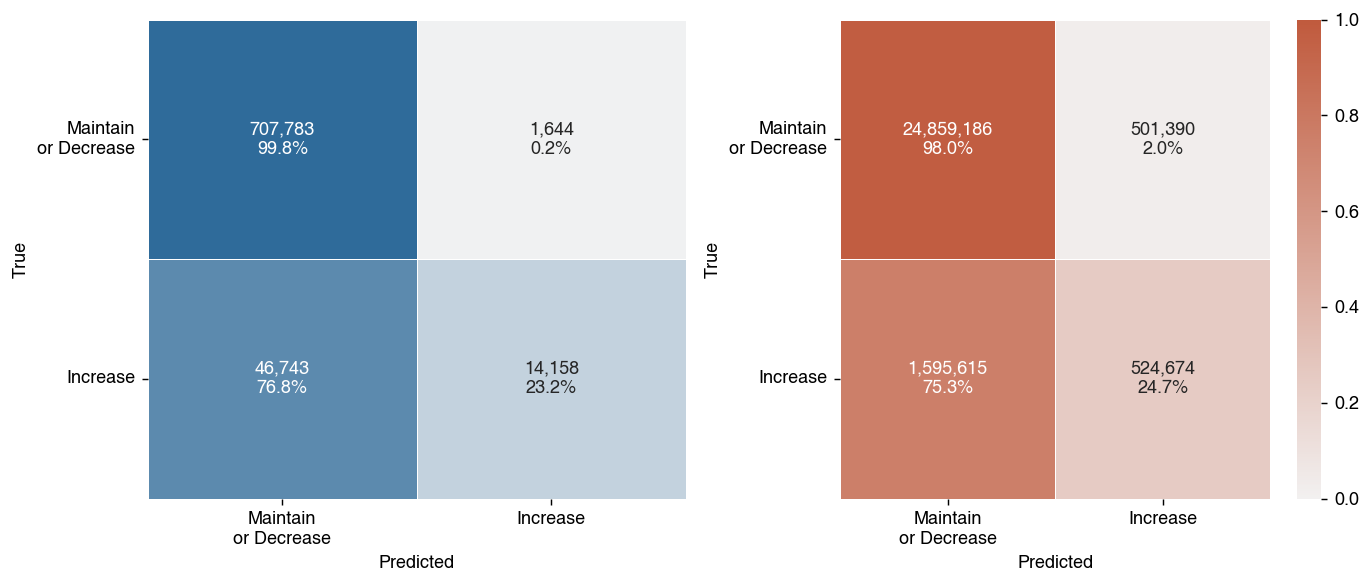

In [15]:
fig, axes = plt.subplots(1, len(records), figsize=(5.4 * len(records), 4.6), squeeze=False)
axes = axes.ravel()

for ax, (dataset, record) in zip(axes, records.items()):
    payload = get_shift_confusion_payload(record['metrics'], prefer_drug_cond=USE_DRUG_COND)
    if payload is None:
        ax.axis('off')
        ax.text(0.5, 0.5, f'{dataset}\nNo SHIFT confusion matrix', ha='center', va='center')
        continue

    cm = payload['cm']
    raw_names = list(payload['class_names'])
    desired_order = ['Label2or3', 'Label1']
    order_idx = [raw_names.index(name) for name in desired_order if name in raw_names]
    order_idx += [i for i in range(len(raw_names)) if i not in order_idx]
    cm = cm[np.ix_(order_idx, order_idx)]
    display_name = {
        'Label1': 'Increase',
        'Label2or3': 'Maintain\nor Decrease',
    }
    class_names = [display_name.get(raw_names[i], raw_names[i]) for i in order_idx]
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{int(cm[i, j]):,}\n{cm_norm[i, j]:.1%}'

    cmap = sns.light_palette(PALETTE.get(dataset, '#333333'), as_cmap=True)
    sns.heatmap(
        cm_norm,
        annot=annot,
        fmt='',
        cmap=cmap,
        vmin=0,
        vmax=1,
        cbar=(dataset == list(records.keys())[-1]),
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

fig.tight_layout()
plt.show()

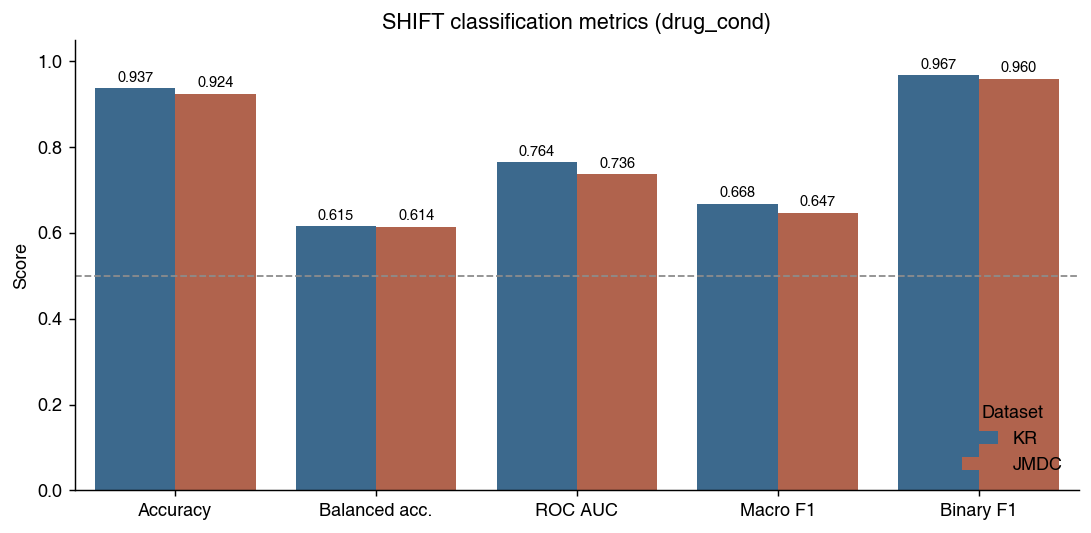

In [9]:
shift_plot_cols = ['accuracy', 'balanced_accuracy', 'roc_auc', 'f1_macro', 'f1_binary']
available_cols = [col for col in shift_plot_cols if col in shift_summary and shift_summary[col].notna().any()]
shift_plot_df = shift_summary[['dataset', *available_cols]].melt(
    id_vars='dataset', var_name='metric', value_name='value'
).dropna(subset=['value'])

metric_labels = {
    'accuracy': 'Accuracy',
    'balanced_accuracy': 'Balanced acc.',
    'roc_auc': 'ROC AUC',
    'f1_macro': 'Macro F1',
    'f1_binary': 'Binary F1',
}
shift_plot_df['metric'] = shift_plot_df['metric'].map(metric_labels)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
sns.barplot(
    data=shift_plot_df,
    x='metric',
    y='value',
    hue='dataset',
    palette=PALETTE,
    ax=ax,
)
ax.axhline(0.5, color='0.55', linestyle='--', linewidth=1)
ax.set_ylim(0, 1.05)
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_title(f'SHIFT classification metrics ({"drug_cond" if USE_DRUG_COND else "all"})')
ax.legend(title='Dataset', frameon=False, loc='lower right')
add_bar_labels(ax)
fig.tight_layout()
plt.show()

KR Youden threshold = 0.717456


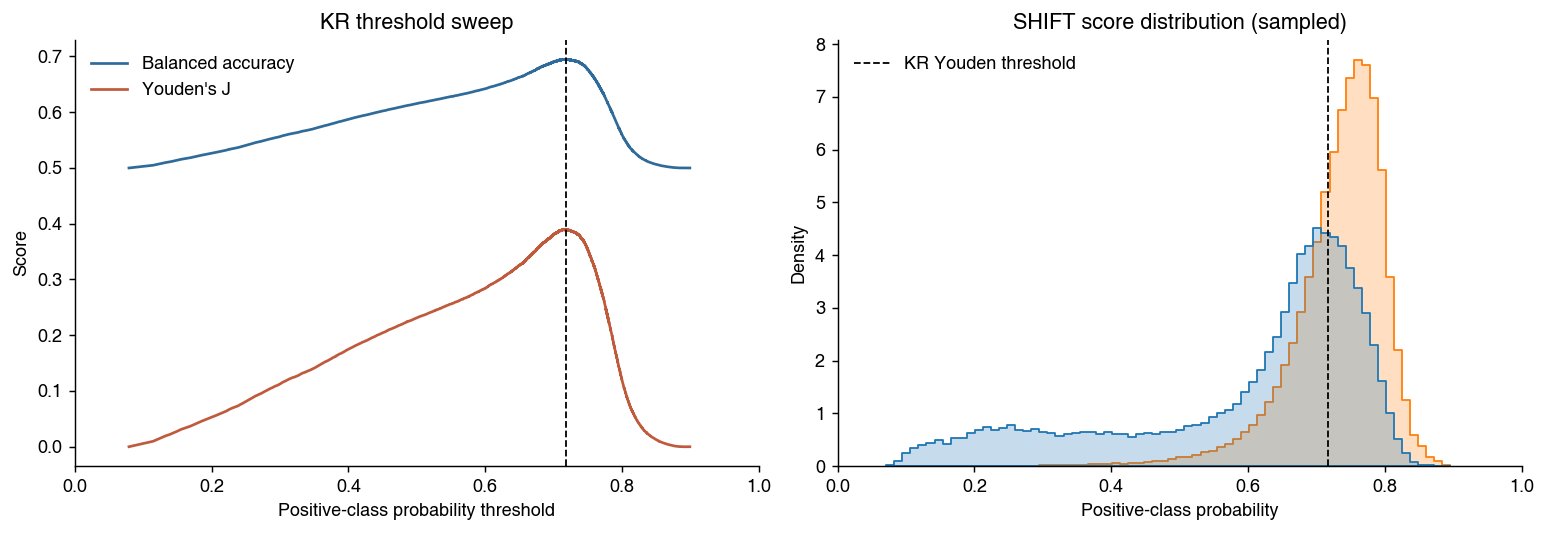

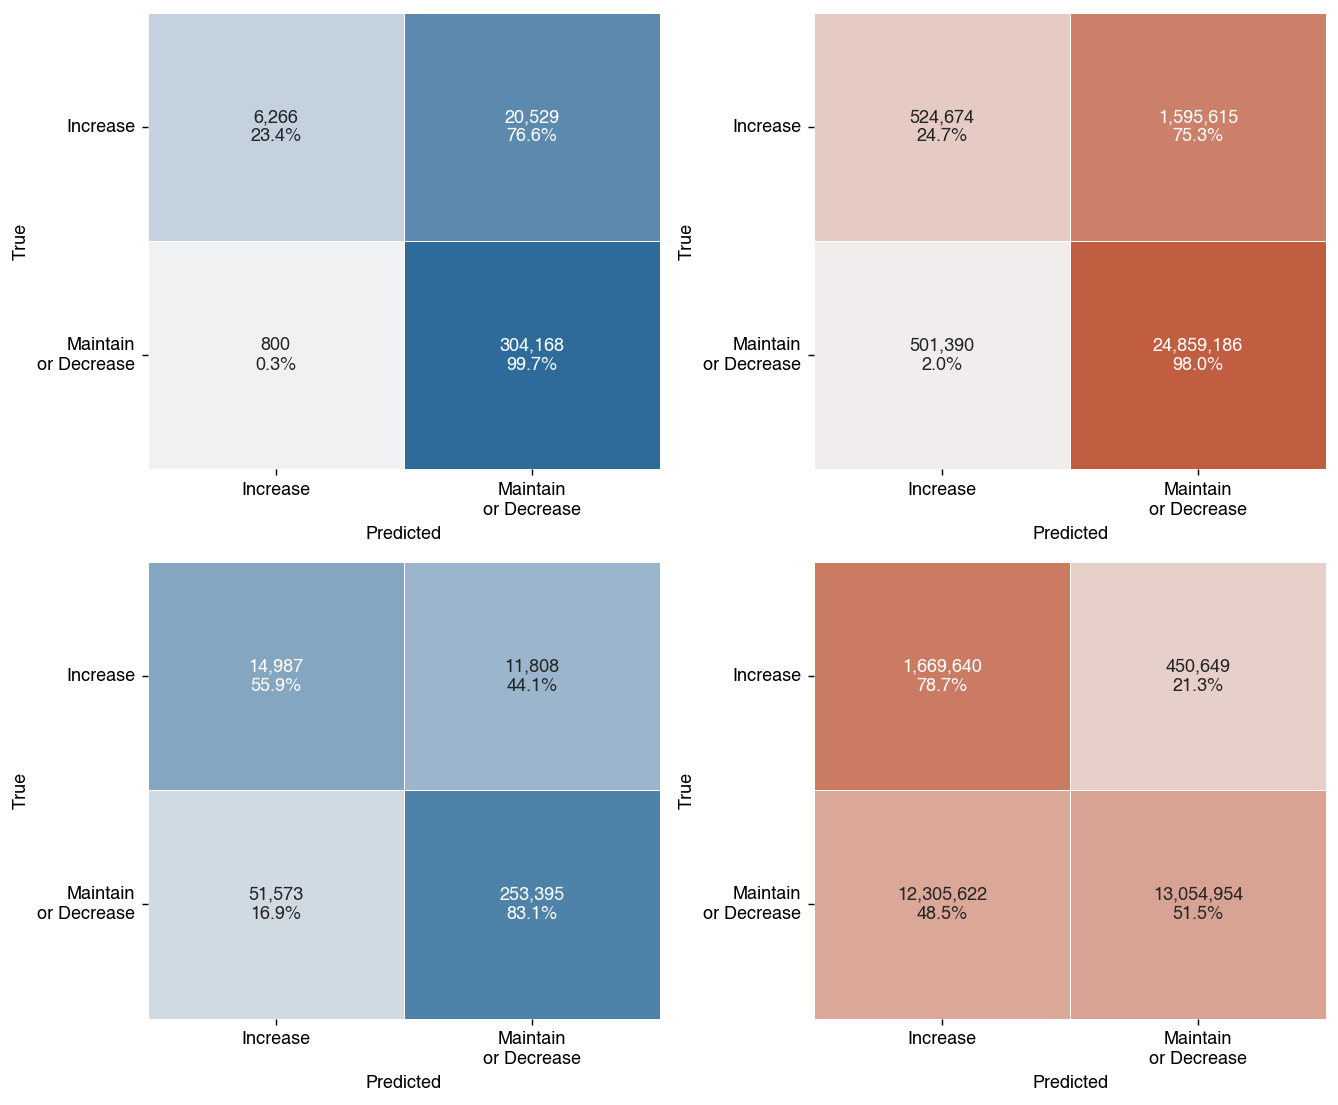

Wrote /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out/shift_confusion_matrices_kr_youden_threshold.pdf


In [18]:
missing_raw = [path for path in RAW_PRED_CONFIG.values() if not Path(path).exists()]
if missing_raw:
    raise FileNotFoundError('Missing raw prediction files:\n' + '\n'.join(f'  - {p}' for p in missing_raw))

shift_raw = {dataset: load_shift_raw(path, prefer_drug_cond=USE_DRUG_COND) for dataset, path in RAW_PRED_CONFIG.items()}
kr_threshold, kr_youden, kr_curve = find_youden_threshold(shift_raw['KR']['binary_target'], shift_raw['KR']['score'])
print(f'KR Youden threshold = {kr_threshold:.6f}')

threshold_rows = []
for dataset, raw in shift_raw.items():
    threshold_rows.append(threshold_metrics(raw['binary_target'], raw['score'], 0.5, dataset, 'default 0.5'))
    threshold_rows.append(threshold_metrics(raw['binary_target'], raw['score'], kr_threshold, dataset, 'KR Youden'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(kr_curve['threshold'], kr_curve['balanced_accuracy'], label='Balanced accuracy', color='#2F6B9A')
axes[0].plot(kr_curve['threshold'], kr_curve['youden'], label="Youden's J", color='#C05A3D')
axes[0].axvline(kr_threshold, color='black', linestyle='--', linewidth=1)
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Positive-class probability threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('KR threshold sweep')
axes[0].legend(frameon=False)

score_parts = []
for dataset, raw in shift_raw.items():
    label_names = np.where(raw['binary_target'] == 1, raw['positive_label'], raw['negative_label'])
    score_parts.append(_sample_for_plot(pd.DataFrame({'dataset': dataset, 'score': raw['score'], 'target_label': label_names})))
score_df = pd.concat(score_parts, ignore_index=True)
sns.histplot(data=score_df, x='score', hue='target_label', stat='density', common_norm=False, element='step', bins=70, ax=axes[1])
axes[1].axvline(kr_threshold, color='black', linestyle='--', linewidth=1, label='KR Youden threshold')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Positive-class probability')
axes[1].set_title('SHIFT score distribution (sampled)')
axes[1].legend(frameon=False)
fig.tight_layout()
threshold_curve_path = OUT_DIR / 'shift_youden_threshold_kr_jmdc.pdf'
fig.savefig(threshold_curve_path, bbox_inches='tight')
plt.show()
# print(f'Wrote {threshold_curve_path}')

plot_threshold_confusion_matrices(threshold_rows, shift_raw, OUT_DIR / 'shift_confusion_matrices_kr_youden_threshold.pdf')

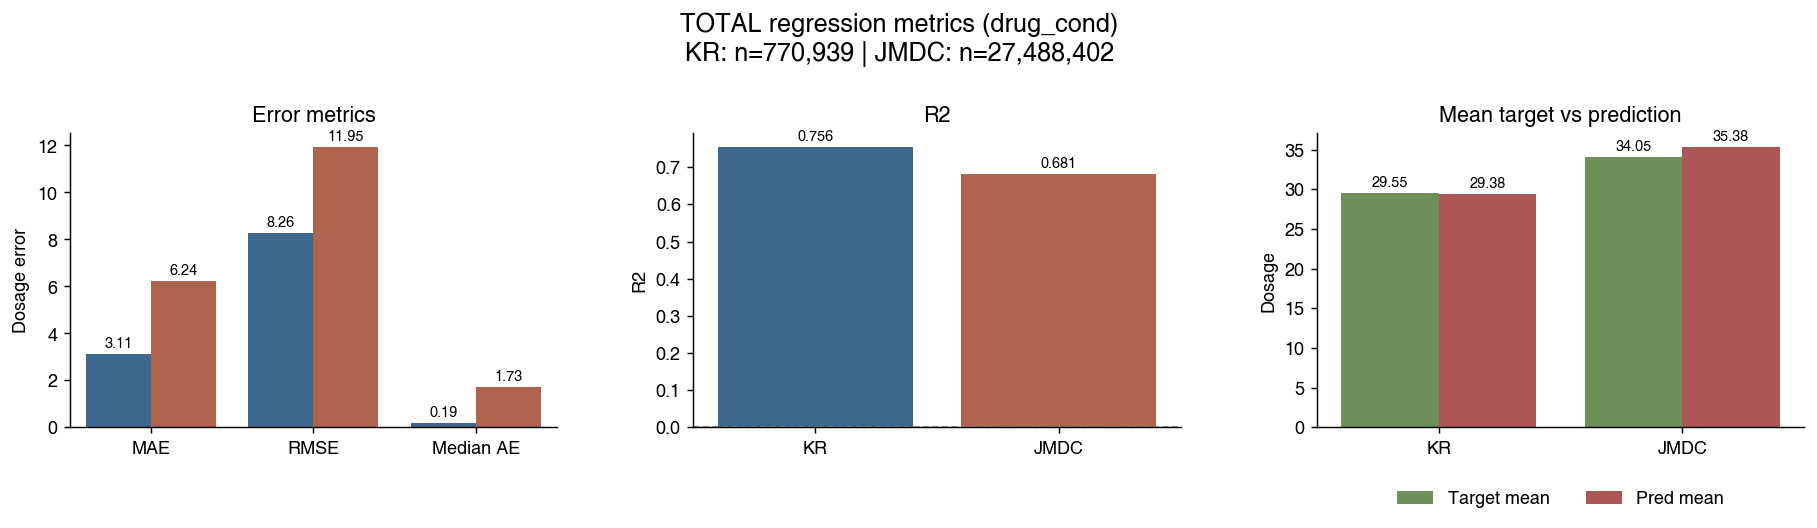

In [7]:
total_numeric = total_summary.copy()
for col in ['mae', 'rmse', 'median_ae', 'r2', 'mean_target', 'mean_pred', 'support']:
    if col in total_numeric:
        total_numeric[col] = pd.to_numeric(total_numeric[col], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))

error_cols = ['mae', 'rmse', 'median_ae']
error_df = total_numeric[['dataset', *error_cols]].melt(
    id_vars='dataset', var_name='metric', value_name='value'
).dropna(subset=['value'])
error_df['metric'] = error_df['metric'].map({
    'mae': 'MAE',
    'rmse': 'RMSE',
    'median_ae': 'Median AE',
})
sns.barplot(data=error_df, x='metric', y='value', hue='dataset', palette=PALETTE, ax=axes[0])
axes[0].set_title('Error metrics')
axes[0].set_xlabel('')
axes[0].set_ylabel('Dosage error')
axes[0].legend_.remove()
add_bar_labels(axes[0], fmt='{:.2f}')

r2_df = total_numeric[['dataset', 'r2']].dropna(subset=['r2'])
sns.barplot(data=r2_df, x='dataset', y='r2', hue='dataset', palette=PALETTE, dodge=False, ax=axes[1])
axes[1].axhline(0, color='0.55', linestyle='--', linewidth=1)
axes[1].set_title('R2')
axes[1].set_xlabel('')
axes[1].set_ylabel('R2')
if axes[1].legend_ is not None:
    axes[1].legend_.remove()
add_bar_labels(axes[1], fmt='{:.3f}')

mean_df = total_numeric[['dataset', 'mean_target', 'mean_pred']].melt(
    id_vars='dataset', var_name='metric', value_name='value'
).dropna(subset=['value'])
mean_df['metric'] = mean_df['metric'].map({'mean_target': 'Target mean', 'mean_pred': 'Pred mean'})
sns.barplot(data=mean_df, x='dataset', y='value', hue='metric', palette=['#6A994E', '#BC4749'], ax=axes[2])
axes[2].set_title('Mean target vs prediction')
axes[2].set_xlabel('')
axes[2].set_ylabel('Dosage')
axes[2].legend(title='', frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=2)
add_bar_labels(axes[2], fmt='{:.2f}')

support_text = ' | '.join(
    f'{row.dataset}: n={int(row.support):,}'
    for row in total_numeric.itertuples()
    if pd.notna(row.support)
)
fig.suptitle(f'TOTAL regression metrics ({"drug_cond" if USE_DRUG_COND else "all"})\n{support_text}', y=0.98, fontsize=14)
fig.subplots_adjust(left=0.06, right=0.98, bottom=0.22, top=0.76, wspace=0.28)
plt.show()

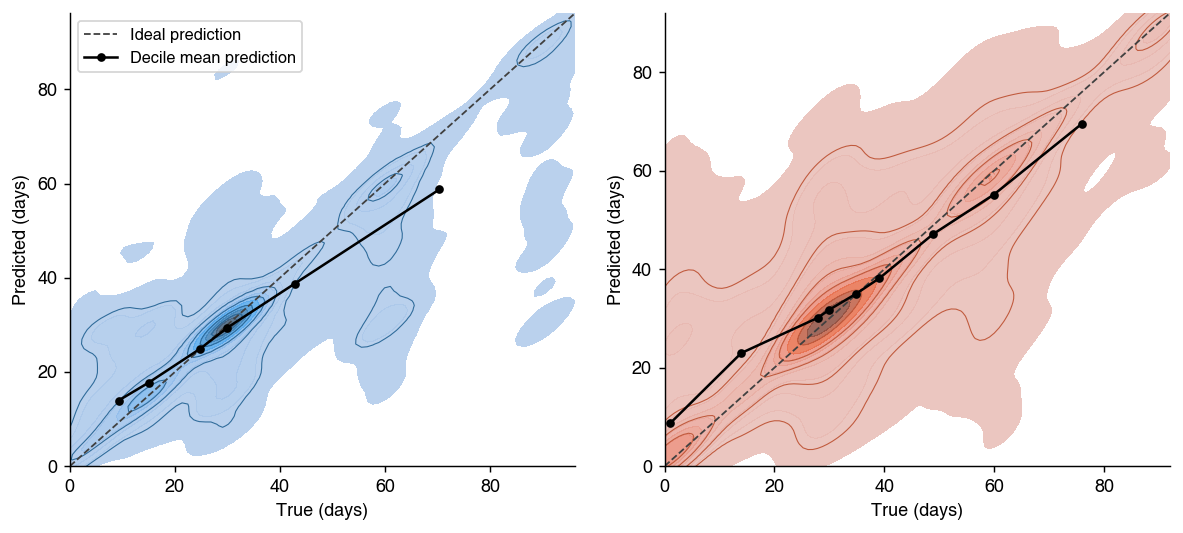

Wrote /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out/total_predicted_vs_true_kr_jmdc.pdf


In [8]:
total_raw = {dataset: load_total_raw(path, prefer_drug_cond=USE_DRUG_COND) for dataset, path in RAW_PRED_CONFIG.items()}
plot_total_predicted_vs_true(total_raw, OUT_DIR / 'total_predicted_vs_true_kr_jmdc.pdf')